In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from utils import generate_laplacian, get_circuit_unitary
from foqcs_lcu.foqcs_lcu import select_foqcs_lcu, sub_prep_foqcs_lcu

from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliGate

from qiskit import transpile
from qiskit_aer import AerSimulator

In [2]:
def PauliDecomposition(matrix, sparse=False, PauliStringInit="", output="Lists", tolerance=1e-6):
    """
        Computes the Pauli decomposition of a square matrix.

        Iteratively splits tensor factors off and decomposes those smaller
        matrices. This is done using submatrices of the original matrix.
        The Pauli strings are generated in each step.

        Args:
            matrix: Matrix to be decomposed
                    (Preferably numpy array/scipysparse).
            output: How the output should be generated.
            sparse: Whether matrix is in sparse format.
            PauliStringInit: For recursive computation.
            tolerance: Threshold below which coefficients are ignored.

        Returns:
            decomposition/outString: String of 1XYZ with their factors.
    """
    matDim = matrix.shape[0]
    qBitDim = math.ceil(np.log(matDim) / np.log(2))

    # Pad, if dimension is not a power of 2
    padDim = 2**qBitDim - matDim
    if padDim != 0:  # This condition states that the padding happens only if needed
        if sparse:
            indxptr = np.pad(matrix.indptr, ((0, padDim), (0, padDim)))
            matrix = csr_matrix((matrix.data, matrix.indices, indxptr))
        else:
            matrix = np.pad(matrix, ((0, padDim), (0, padDim)))

    decomposition = []

    if output == "Lists":
        Strings = []
        Coeffs = []

    # Output for dimension 1
    if qBitDim == 0:
        if abs(matrix[0, 0]) > tolerance:  # Ignore small coefficients
            if output == "Lists":
                Strings.append(PauliStringInit)
                try:
                    Coeffs.append(matrix[0, 0])
                except:
                    Coeffs.append(matrix[0, 0].numpy())
            else:
                decomposition = [f"{matrix[0, 0]}, {PauliStringInit}. "]

    # Calculates the tensor product coefficients via the sliced submatrices.
    if qBitDim > 0:
        halfDim = int(2**(qBitDim - 1))

        coeff1 = 0.5 * (matrix[0:halfDim, 0:halfDim] + matrix[halfDim:, halfDim:])
        coeffX = 0.5 * (matrix[halfDim:, 0:halfDim] + matrix[0:halfDim, halfDim:])
        coeffY = -1.j * 0.5 * (matrix[halfDim:, 0:halfDim] - matrix[0:halfDim, halfDim:])
        coeffZ = 0.5 * (matrix[0:halfDim, 0:halfDim] - matrix[halfDim:, halfDim:])

        coefficients = {"I": coeff1, "X": coeffX, "Y": coeffY, "Z": coeffZ}

        matrix = None

        # Recursion for the submatrices
        for c in coefficients:
            mat = coefficients[c]
            if sparse:
                nonZero = len(mat.nonzero()[0])
            else:
                nonZero = np.any(np.abs(mat) > tolerance)  # Check for significant values
            
            # Ignore zero or near-zero matrices
            if nonZero:
                subDec = PauliDecomposition(
                    mat, sparse, f"{PauliStringInit}{c}", output, tolerance
                )
                if output == "Lists":
                    Strings.extend(subDec[0])
                    Coeffs.extend(subDec[1])
                else:
                    decomposition.append(subDec)

    if output == "Lists":
        return [Strings, Coeffs]
    else:
        outputString = "".join(decomposition)
        return outputString

# Test for a Dirichlet Laplacian

Matrix size 4x4

In [63]:
ops, coefs = PauliDecomposition(generate_laplacian([4], analytic_normalize=True).todense())
ops2 = []

coefs = np.sqrt(np.array(coefs))

for op in ops:
    print(op)
    ops2.append(PauliGate(op))
    print(PauliGate(op))

ops = ops2

II
Instruction(name='pauli', num_qubits=2, num_clbits=0, params=['II'])
IX
Instruction(name='pauli', num_qubits=2, num_clbits=0, params=['IX'])
XX
Instruction(name='pauli', num_qubits=2, num_clbits=0, params=['XX'])
YY
Instruction(name='pauli', num_qubits=2, num_clbits=0, params=['YY'])


In [64]:
L = 2
subprep = sub_prep_foqcs_lcu(coefs, normalization=True, compact=True)
subprepL = sub_prep_foqcs_lcu(coefs.conj(), normalization=True, compact=True)
select = select_foqcs_lcu(L)

qc = QuantumCircuit(3 * L)
qc.append(subprep, list(range(0, L)))
qc.append(select, list(range(3 * L)))
qc.append(subprepL.inverse(), list(range(L)))
op = qc.to_instruction()
qc.draw()

┌──────────┐┌─────────┐┌─────────────────┐
q_0: ┤0         ├┤0        ├┤0                ├
     │  subPREP ││         ││  circuit-780_dg │
q_1: ┤1         ├┤1        ├┤1                ├
     └──────────┘│         │└─────────────────┘
q_2: ────────────┤2        ├───────────────────
                 │  SELECT │                   
q_3: ────────────┤3        ├───────────────────
                 │         │                   
q_4: ────────────┤4        ├───────────────────
                 │         │                   
q_5: ────────────┤5        ├───────────────────
                 └─────────┘

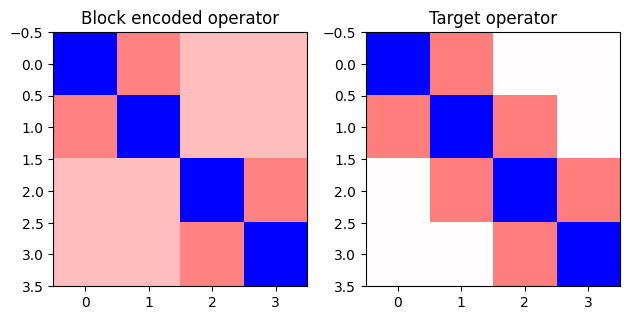

In [85]:
qc2 = QuantumCircuit(3 * L)
qc2.append(op, [4, 5, 2, 3, 0, 1])
qc2.decompose().draw()

fig, axs = plt.subplots(1, 2)
axs[0].imshow(get_circuit_unitary(qc2, [2]), cmap="seismic", vmin=-1, vmax=1)
axs[0].set_title("Block encoded operator")

axs[1].imshow(generate_laplacian([4], analytic_normalize=True).todense(), cmap="seismic", vmin=-1, vmax=1)
axs[1].set_title("Target operator")

fig.tight_layout()
plt.show()

# FOQCS-LCU $X \otimes X$ operator block encoding test

In [103]:
# Matrix definitions used to verify block encodings
eye = np.eye(2)
x = np.array([[0, 1], [1, 0]])
y = np.array([[0, -1j], [1j, 0]])
z = np.array([[1, 0], [0, -1]])

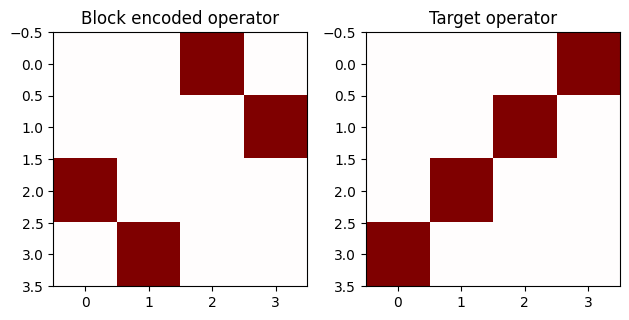

In [101]:
ops, coefs = PauliDecomposition(generate_laplacian([4], analytic_normalize=True).todense())
ops2 = []

coefs = np.sqrt(np.array(coefs))

for op in ops:
    ops2.append(PauliGate(op))

# Modify coefficients for desired XX operator block encoding
ops = ops2
coefs[0] = 0
coefs[1] = 0
coefs[2] = 1
coefs[3] = 0

# Prepare circuit
L = 2
subprep = sub_prep_foqcs_lcu(coefs, normalization=True, compact=True)
subprepL = sub_prep_foqcs_lcu(coefs.conj(), normalization=True, compact=True)
select = select_foqcs_lcu(L)

qc = QuantumCircuit(3 * L)
qc.append(subprep, list(range(0, L)))
qc.append(select, list(range(3 * L)))
qc.append(subprepL.inverse(), list(range(L)))
op = qc.to_instruction()
qc.draw()

qc2 = QuantumCircuit(3 * L)
qc2.append(op, [4, 5, 2, 3, 0, 1])
qc2.decompose().draw()

# Plot and compare between simulation and expected resutls
fig, axs = plt.subplots(1, 2)
axs[0].imshow(get_circuit_unitary(qc2, [2]), cmap="seismic", vmin=-1, vmax=1)
axs[0].set_title("Block encoded operator")

axs[1].imshow(np.kron(x, x), cmap="seismic", vmin=-1, vmax=1)
axs[1].set_title("Target operator")

fig.tight_layout()
plt.show()